<a href="https://colab.research.google.com/github/kimheeseo/LSCNS/blob/main/Hedeboe_Fig4_Repeater_Power_Colab_Report.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SubOptic 2025 Fig. 4 재구성 보고서
## 최대전력전달 조건, 리피터 수 산정, SC/DC 공간분할 시뮬레이션

**대상 자료**

- 논문: *Capacity and Cost Investigations of Long-Span-Length, High-Number Spatial-Pairs Trans-Oceanic Cables* (Hedeboe et al., SubOptic 2025)
- 저자 코드: `Opt_cap_extended_model(7).py`, `snr_calculator_Silas(7).py`

### 먼저 결론

Fig. 4의 리피터 수는 최대전력전달 정리에서 바로 하나의 값으로 계산한 것이 아니다. 각 후보 span에 대해

1. 코드 정의로 $N_{rep}=\lfloor L_{tot}/L_{span}\rfloor$을 만들고,
2. 케이블의 최대 공급전력으로 EDFA 출력 상한을 계산하고,
3. Generalized Droop/GN 모델로 SNR과 Shannon 용량을 계산한 후,
4. 12-SC-FP 기준 용량을 유지할 수 있는 **가장 긴 span**을 골라
5. 그 span의 $N_{rep}$과 $N_{amp}=2N_{rep}N_{FP}N_{cores}$를 Fig. 4(b)-(d)에 표시한다.

즉, 최대전력전달 조건은 **가능한 EDFA 출력의 상한**을 만들고, 리피터 수는 광전송 성능과 전력 제약을 함께 탐색해 결정된다.

> 재현성 판정: 첨부된 두 파일에는 원 함수가 요구하는 2차원 EDFA 효율표 $\eta_{eo}(G,P_s)$, `help_functions.py`, Fig. 4 상위 실행 코드가 없다. 또한 논문 본문의 2-dB back-off와 18 dBm 제약이 제공 함수 안에서는 완성되어 있지 않다. 아래 결과는 식과 제공 코드를 보존한 **감사 가능한 재구성**이며, 출판 그림의 픽셀 단위 완전 복제는 아니다.


## 1. 최대전력전달 조건에서 식 (7), (8)이 나오는 과정

총 케이블 도체 저항을 $R_c=R_0L_{tot}=R_0N_{sp}L_{span}$, 전체 리피터를 등가 부하 $R_L$로 보면 부하에 전달되는 전력은

$$
P_L=I^2R_L=\frac{V_{PFE}^2R_L}{(R_c+R_L)^2}.
$$

$R_L$로 미분하면 $R_L=R_c$에서 최대가 되므로

$$
I_{MPT}=\frac{V_{PFE}}{2R_c},\qquad
P_{L,max}=\frac{V_{PFE}^2}{4R_c}.
$$

이를 $N_{rep}$개 리피터가 나누면 논문의 식 (7)이 된다.

$$
P_{rep,sup}=\frac{V_{PFE}^2}{4R_0L_{tot}N_{rep}}
=\frac{V_{PFE}^2}{4N_{sp}L_{span}R_0N_{rep}}.
$$

리피터 하나에는 공간 pair당 양방향 EDFA 두 개가 있으므로 $M_{sp}=N_{FP}N_{cores}$일 때 EDFA 수는 $2M_{sp}$이다. 회로 소모율 $\epsilon$과 전기-광 변환효율 $\eta_{eo}$를 적용하면 EDFA 한 대의 총 WDM 출력 상한은

$$
P_{s,max}=\frac{(1-\epsilon)\eta_{eo}V_{PFE}^2}
{8R_0L_{tot}N_{rep}M_{sp}}.
$$

$P_s=N_{ch}P_{ch}$로 두면 이것이 논문의 식 (8)과 같다. 주어진 $P_s$에서 허용 가능한 리피터 수의 단순 전력 상한도 쓸 수 있다.

$$
N_{rep}\le \frac{(1-\epsilon)\eta_{eo}V_{PFE}^2}
{8R_0L_{tot}M_{sp}P_s}.
$$

하지만 실제 최적 $N_{rep}$은 이 식만으로 확정할 수 없다. $N_{rep}$을 줄이면 EDFA당 전력은 늘지만 span 손실과 ASE가 커지고, $P_s$를 올리면 NLI가 증가하며, $\eta_{eo}$도 gain과 출력에 따라 달라지기 때문이다.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 30)
pd.set_option('display.width', 160)

P = {
    'alpha_db_km': 0.15,
    'D_s_km_nm': 21e-12,
    'gamma_w_km': 0.81,
    'NF_db': 4.5,
    'epsilon': 0.10,
    'R_ohm_km': 1.0,
    'B_hz': 4.3e12,
    'Rs_hz': 100e9,
    'df_hz': 112.5e9,
    'lambda_nm': 1550.0,
    'Vpfe_v': 18_000.0,
    'p_hard_max_dbm': 18.0,
    'backoff_db': 2.0,
    'eta_constant': 0.023,
}

ETA_MODE = 'reconstructed_surface'  # 'constant_2p3pct'로 바꾸면 완전 투명한 고정 효율 검산
APPLY_2DB_BACKOFF = True

def db2lin(x): return 10**(np.asarray(x)/10)
def lin2db(x): return 10*np.log10(np.asarray(x))
def dbm2w(x): return 10**((np.asarray(x)-30)/10)
def w2dbm(x): return 10*np.log10(np.asarray(x))+30

print('채널 수 B/Δf =', P['B_hz']/P['df_hz'], '(저자 코드는 정수 반올림 없이 이 값을 사용)')
print('실행 모드:', ETA_MODE, '| 2-dB back-off:', APPLY_2DB_BACKOFF)


채널 수 B/Δf = 38.22222222222222 (저자 코드는 정수 반올림 없이 이 값을 사용)
실행 모드: reconstructed_surface | 2-dB back-off: True


## 2. 저자 SNR 코드의 독립 실행형 정리

아래 함수는 `snr_calculator_Silas(7).py`의 `SNR_GD`를 단위와 변수명을 명확히 해 옮긴 것이다. 핵심은 span당 ASE droop $\chi_a$, GN 비선형 droop와 XT를 합친 $\chi_r$를 $N_{rep}$번 누적하는 식이다.

$$
GSNR=\frac{1}{(\chi_a^{-1}\chi_r^{-1})^{N_{rep}}-1}.
$$

원 코드의 `gamma_XT` 주석은 dB라고 적혀 있지만 수식에서는 선형 $1/\mathrm{km}$로 사용된다. 따라서 -80 dB/km는 코드 입력에서 $10^{-8}/\mathrm{km}$로 변환한다.


In [2]:
def snr_gd(Ps_w, Nrep, Ltot_km, fifo_db=0.0, gamma_xt_lin_km=0.0, p=P):
    Ps_w = np.asarray(Ps_w, dtype=float)
    h = 6.62607015e-34
    c_nm_s = 2.99792458e17
    f_hz = c_nm_s / p['lambda_nm']
    Nch = p['B_hz'] / p['df_hz']
    Pch = Ps_w / Nch
    alpha_lin = p['alpha_db_km'] / 4.343
    NF_lin = db2lin(p['NF_db'])
    beta2 = -p['D_s_km_nm'] * p['lambda_nm']**2 / (2*np.pi*c_nm_s)

    actual_span_km = Ltot_km / Nrep
    gain_db = p['alpha_db_km']*actual_span_km + 2*fifo_db
    G_lin = db2lin(gain_db)
    P_ASE = h*f_hz*NF_lin*p['Rs_hz']*(G_lin-1)
    chi_a = (1 + P_ASE/Pch)**-1

    L_eff = (1-np.exp(-alpha_lin*actual_span_km))/alpha_lin
    L_effa = 1/alpha_lin
    alpha_nli = (
        8/27 * p['gamma_w_km']**2 * L_eff**2
        * np.arcsinh(np.pi**2/2*abs(beta2)*L_effa*p['Rs_hz']**2
                     * Nch**(2*p['Rs_hz']/p['df_hz']))
        / (np.pi*abs(beta2)*L_effa*p['Rs_hz']**2)
    )
    snr_1r_nli = 1/(alpha_nli*Pch**2)
    if gamma_xt_lin_km == 0:
        snr_1r = snr_1r_nli
    else:
        snr_1r_xt = 1/(gamma_xt_lin_km*actual_span_km)
        snr_1r = 1/(1/snr_1r_nli + 1/snr_1r_xt)
    chi_r = (1 + 1/snr_1r)**-1
    return 1/((1/chi_a/chi_r)**Nrep - 1)


## 3. 빠진 $\eta_{eo}$ 표의 처리

원 `optimized_capacity_extended`는 `eta[1:,1:]`를 사용하며, 행은 span/gain, 열은 EDFA 출력에 대응한다고 주석에 적혀 있다. 첨부 자료에는 이 표가 없다.

- `constant_2p3pct`: 논문 Fig. 3에서 명시한 2.3%를 고정한다. 수치가 완전히 추적 가능하지만 Fig. 4의 gain-의존 이동을 재현하지 못한다.
- `reconstructed_surface`: 논문 Table 1의 약 2-3.1% 범위를 참고해 gain과 출력에 따른 완만한 표면을 만든다. Fig. 4의 경향 확인용이며 저자의 원 데이터가 아니다.

원 효율표를 받으면 아래 `eta_eo()`만 교체하면 나머지 계산은 그대로 사용할 수 있다.


In [3]:
def eta_eo(gain_db, Ps_w, mode=ETA_MODE, p=P):
    Ps_w = np.asarray(Ps_w, dtype=float)
    if mode == 'constant_2p3pct':
        return np.full_like(Ps_w, p['eta_constant'])

    # Fig. 4 경향 검토를 위한 명시적 surrogate. 저자 효율표가 아님.
    # 저 gain에서는 약 1.85-2.0%, 11.25 dB 부근 약 2.3%, 높은 gain에서 최대 3.1%.
    if gain_db <= 7.5:
        eta_gain = 0.0185
    elif gain_db <= 11.25:
        eta_gain = 0.0185 + ((gain_db-7.5)/3.75)**1.35*0.0045
    else:
        eta_gain = min(0.031, 0.023 + (gain_db-11.25)/7.25*0.008)
    p_norm = np.clip((w2dbm(Ps_w)+5)/23, 0, 1)
    return np.clip(eta_gain*(0.80+0.20*p_norm), 0.016, 0.031)

def capacity_bps(snr_lin, physical_fp, ncores, p=P):
    spatial_pairs = physical_fp*ncores
    Nch = p['B_hz']/p['df_hz']
    return spatial_pairs*Nch*p['Rs_hz']*np.log2(1+snr_lin)

def evaluate_one_nrep(Ltot_km, Nrep, physical_fp, ncores=1,
                      fifo_db=0.0, gamma_xt_lin_km=0.0,
                      eta_mode=ETA_MODE, p=P):
    spatial_pairs = physical_fp*ncores
    p_grid = dbm2w(np.linspace(-20, p['p_hard_max_dbm'], 500))
    p_nlt_grid = dbm2w(np.linspace(-20, 24, 600))
    snr_nlt = snr_gd(p_nlt_grid, Nrep, Ltot_km, fifo_db, gamma_xt_lin_km, p)
    p_nlt = p_nlt_grid[np.nanargmax(snr_nlt)]

    actual_span = Ltot_km/Nrep
    gain_db = p['alpha_db_km']*actual_span + 2*fifo_db
    eta_vec = eta_eo(gain_db, p_grid, eta_mode, p)
    p_elec_ceiling = (
        p['Vpfe_v']**2*(1-p['epsilon'])*eta_vec
        /(8*p['R_ohm_km']*Ltot_km*Nrep*spatial_pairs)
    )
    feasible = p_grid <= p_elec_ceiling
    if APPLY_2DB_BACKOFF:
        feasible &= p_grid <= p_nlt/db2lin(p['backoff_db'])
    feasible &= p_grid <= dbm2w(p['p_hard_max_dbm'])

    if not np.any(feasible):
        return None
    idxs = np.flatnonzero(feasible)
    snr_feasible = snr_gd(p_grid[idxs], Nrep, Ltot_km, fifo_db, gamma_xt_lin_km, p)
    idx = idxs[np.nanargmax(snr_feasible)]
    snr = snr_gd(p_grid[idx], Nrep, Ltot_km, fifo_db, gamma_xt_lin_km, p)
    return {
        'Ltot_km': Ltot_km,
        'physical_fp': physical_fp,
        'ncores': ncores,
        'spatial_pairs': spatial_pairs,
        'Nrep': int(Nrep),
        'span_km': actual_span,
        'gain_db': gain_db,
        'eta': float(eta_vec[idx]),
        'Ps_w': float(p_grid[idx]),
        'Ps_dbm': float(w2dbm(p_grid[idx])),
        'Pelec_ceiling_dbm': float(w2dbm(p_elec_ceiling[idx])),
        'P_nlt_dbm': float(w2dbm(p_nlt)),
        'SNR_db': float(lin2db(snr)),
        'capacity_Tbps': float(capacity_bps(snr, physical_fp, ncores, p)/1e12),
        'amplifiers': int(2*Nrep*spatial_pairs),
    }


## 4. 최대전력전달 수치 검산

아래 두 예는 $\eta_{eo}=2.3\%$ 고정으로 전력식 자체를 검산한다.

- 6,000 km, 50 km span: $N_{rep}=120$. 케이블 전체 부하로 전달되는 최대 전력은 13.5 kW이고, EDFA당 광출력 상한은 약 97 mW(19.87 dBm)이므로 18 dBm/비선형 back-off가 먼저 작동한다.
- 15,000 km, 75 km span: $N_{rep}=200$. EDFA당 상한은 약 23.3 mW(13.67 dBm)로 낮아져 전력 제한이 지배적이다. 제공 SNR 코드에 넣으면 12-SC-FP 용량이 약 130 Tb/s로 논문 본문의 15,000 km benchmark 설명과 잘 맞는다.


In [4]:
def mpt_audit(Ltot_km, span_km, physical_fp=12, ncores=1, eta=0.023, p=P):
    Nrep = int(np.floor(Ltot_km/span_km))
    Rc = p['R_ohm_km']*Ltot_km
    I = p['Vpfe_v']/(2*Rc)
    Pload_total = p['Vpfe_v']**2/(4*Rc)
    Prep = Pload_total/Nrep
    amps_per_rep = 2*physical_fp*ncores
    Psmax = Prep*(1-p['epsilon'])*eta/amps_per_rep
    snr = snr_gd(Psmax, Nrep, Ltot_km)
    cap = capacity_bps(snr, physical_fp, ncores)/1e12
    return [Ltot_km, span_km, Nrep, Rc, I, Pload_total/1e3, Prep, Psmax*1e3, w2dbm(Psmax), lin2db(snr), cap]

audit = pd.DataFrame(
    [mpt_audit(6000, 50), mpt_audit(15000, 75)],
    columns=['Ltot_km','nominal_span_km','Nrep','Rc_ohm','I_MPT_A','Pload_total_kW',
             'P_per_repeater_W','Psmax_per_EDFA_mW','Psmax_dBm','SNR_if_at_ceiling_dB','Capacity_Tbps']
)
print(audit.round(3).to_string(index=False))


 Ltot_km  nominal_span_km  Nrep  Rc_ohm  I_MPT_A  Pload_total_kW  P_per_repeater_W  Psmax_per_EDFA_mW  Psmax_dBm  SNR_if_at_ceiling_dB  Capacity_Tbps
    6000               50   120  6000.0      1.5            13.5             112.5             97.031     19.869                13.301        205.683
   15000               75   200 15000.0      0.6             5.4              27.0             23.287     13.671                 7.884        130.111


## 5. Fig. 4 계산 알고리즘

### 5.1 12-SC-FP benchmark

각 $L_{tot}=6,000\ldots15,000$ km에서 실제 span이 50 km 이상인 후보를 계산하고, 전력/2-dB/18-dBm 제약 아래 용량이 가장 큰 점을 benchmark로 둔다.

### 5.2 더 많은 공간 pair로 용량 분배

- SC: 16, 20, 24, 28, 32 physical FP, $N_{cores}=1$.
- DC: 6, 8, 10, 12, 14, 16 physical FP, $N_{cores}=2$, FIFO는 입출력 각각 0.3 dB, XT는 -80 dB/km = $10^{-8}$/km.
- 각 후보에서 최대 달성 용량이 benchmark 이상이면, benchmark를 만족하는 후보 중 가장 긴 span을 채택한다.
- 만족하지 못하면 Fig. 4(a)용 최대 달성 용량만 남기고 span/repeater/amplifier 값은 제외한다.

원 코드의 `floor` 정의를 재현하되 같은 $N_{rep}$을 만드는 중복 span 후보는 제거한다. 따라서 표와 그래프의 `span_km`은 실제 $L_{tot}/N_{rep}$이다.


In [5]:
def candidate_curve(Ltot_km, physical_fp, ncores=1, fifo_db=0.0,
                    gamma_xt_lin_km=0.0, eta_mode=ETA_MODE, p=P):
    nominal_spans = np.arange(30.0, 260.01, 0.5)
    nreps = np.unique(np.floor(Ltot_km/nominal_spans).astype(int))
    rows = []
    for n in nreps:
        row = evaluate_one_nrep(Ltot_km, int(n), physical_fp, ncores,
                                fifo_db, gamma_xt_lin_km, eta_mode, p)
        if row is not None:
            rows.append(row)
    return pd.DataFrame(rows).sort_values('span_km').reset_index(drop=True)

def benchmark_for_length(Ltot_km, eta_mode=ETA_MODE, p=P):
    curve = candidate_curve(Ltot_km, 12, 1, 0.0, 0.0, eta_mode, p)
    curve = curve[curve.span_km >= 50.0]
    return curve.loc[curve.capacity_Tbps.idxmax()].to_dict()

def distributed_case(Ltot_km, physical_fp, ncores, benchmark_Tbps,
                     fifo_db=0.0, gamma_xt_lin_km=0.0,
                     eta_mode=ETA_MODE, p=P):
    curve = candidate_curve(Ltot_km, physical_fp, ncores, fifo_db,
                            gamma_xt_lin_km, eta_mode, p)
    best = curve.loc[curve.capacity_Tbps.idxmax()].to_dict()
    feasible = curve[curve.capacity_Tbps >= benchmark_Tbps]
    if len(feasible):
        selected = feasible.loc[feasible.span_km.idxmax()].to_dict()
        selected['sustainable'] = True
        selected['supported_capacity_Tbps'] = benchmark_Tbps
    else:
        selected = best.copy()
        selected['sustainable'] = False
        selected['supported_capacity_Tbps'] = best['capacity_Tbps']
    selected['max_achievable_capacity_Tbps'] = best['capacity_Tbps']
    return selected

lengths = np.arange(6000, 15001, 500)
bench_rows, sc_rows, dc_rows = [], [], []
for L in lengths:
    b = benchmark_for_length(float(L))
    b['supported_capacity_Tbps'] = b['capacity_Tbps']
    b['sustainable'] = True
    bench_rows.append(b)
    for fp in [16,20,24,28,32]:
        sc_rows.append(distributed_case(float(L), fp, 1, b['capacity_Tbps']))
    for fp in [6,8,10,12,14,16]:
        dc_rows.append(distributed_case(float(L), fp, 2, b['capacity_Tbps'],
                                        fifo_db=0.3, gamma_xt_lin_km=10**(-80/10)))

bench_df = pd.DataFrame(bench_rows)
sc_df = pd.DataFrame(sc_rows)
dc_df = pd.DataFrame(dc_rows)
print('계산 완료:', len(bench_df), 'benchmark /', len(sc_df), 'SC /', len(dc_df), 'DC cases')


계산 완료: 19 benchmark / 95 SC / 114 DC cases


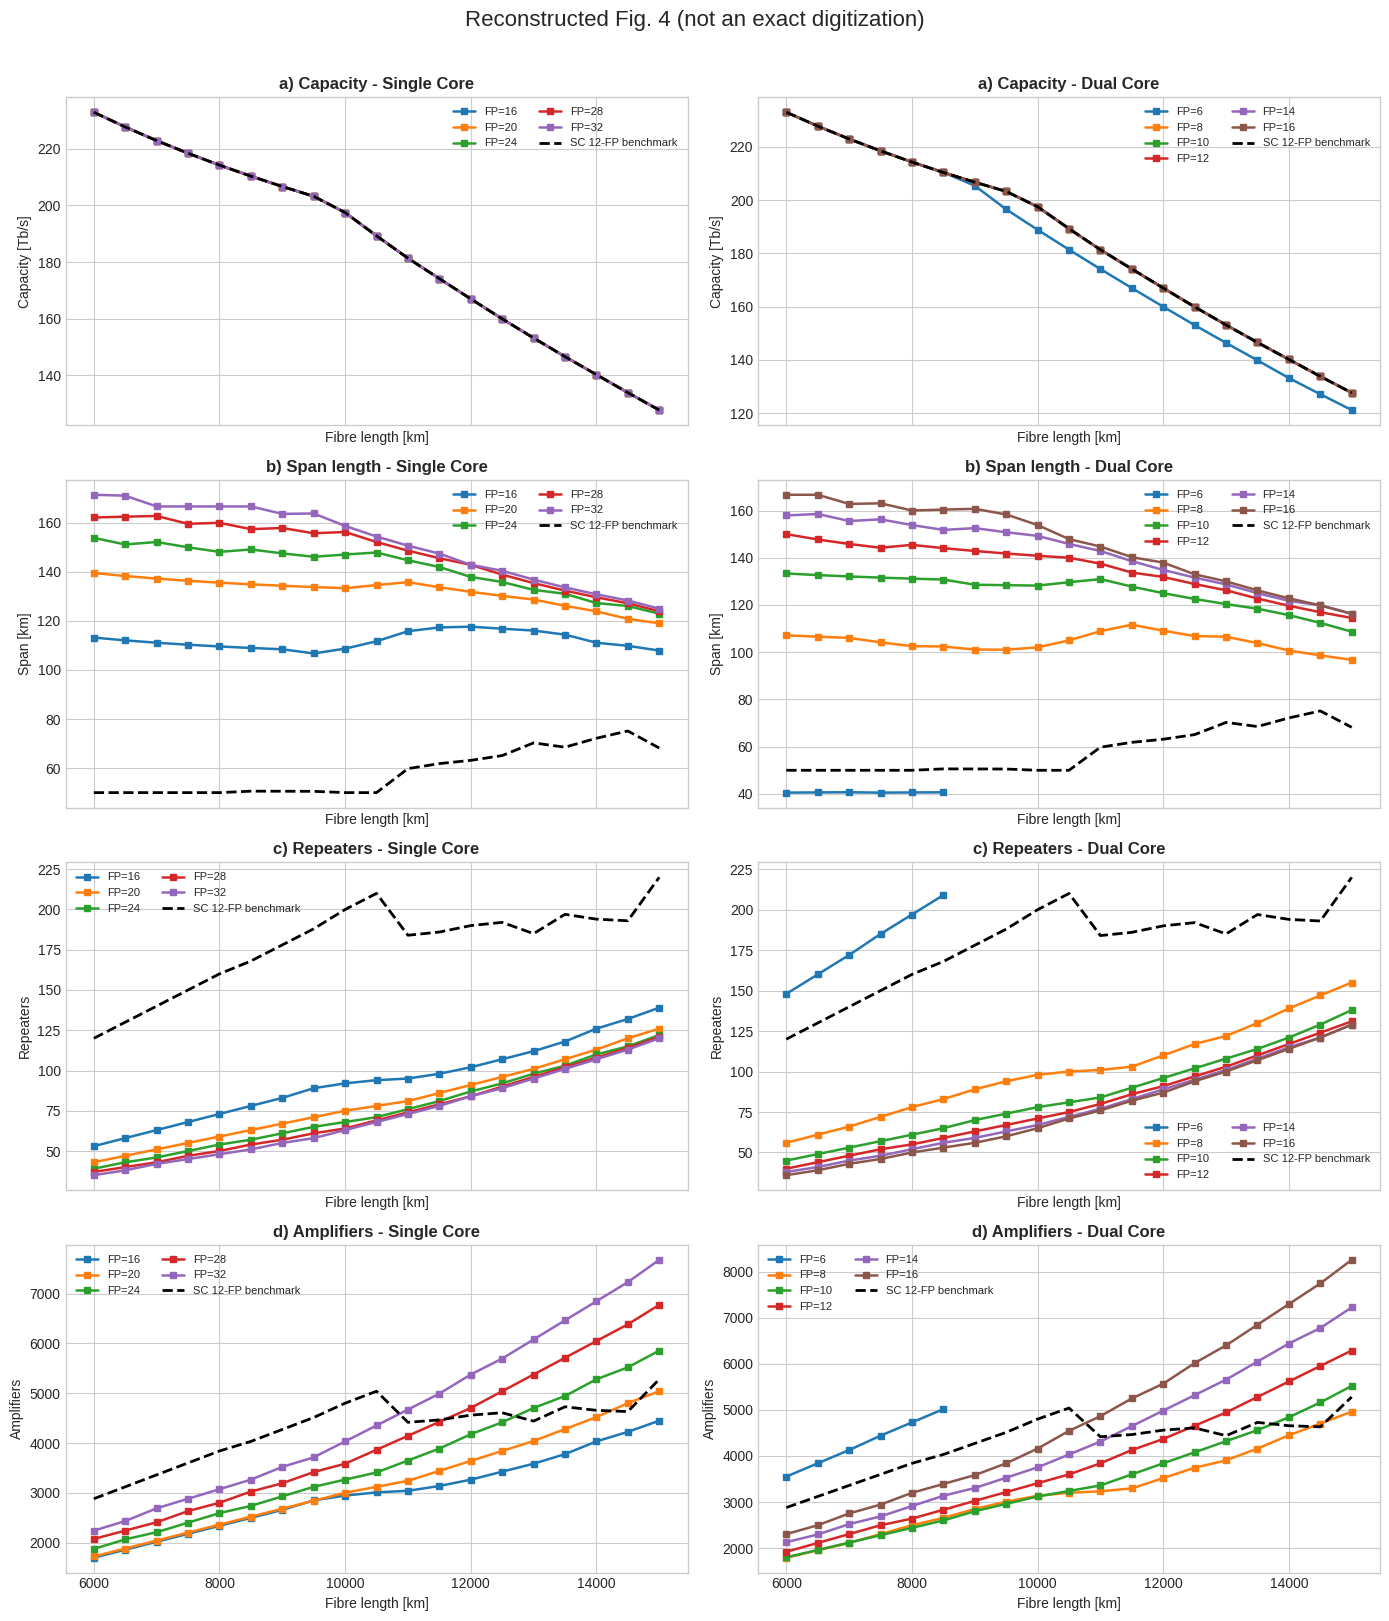

In [6]:
fig, axes = plt.subplots(4, 2, figsize=(14, 16), sharex='col')

def panel(ax, df, y, title, fps):
    for fp in fps:
        d = df[df.physical_fp == fp].sort_values('Ltot_km')
        if y == 'supported_capacity_Tbps':
            yy = d[y]
        else:
            yy = d[y].where(d.sustainable)
        ax.plot(d.Ltot_km, yy, marker='s', ms=4, lw=1.8, label=f'FP={fp}')
    by = {'supported_capacity_Tbps':'capacity_Tbps', 'span_km':'span_km',
          'Nrep':'Nrep', 'amplifiers':'amplifiers'}[y]
    ax.plot(bench_df.Ltot_km, bench_df[by], 'k--', lw=2, label='SC 12-FP benchmark')
    ax.set_title(title, fontweight='bold')
    ax.legend(fontsize=8, ncol=2)

panel(axes[0,0], sc_df, 'supported_capacity_Tbps', 'a) Capacity - Single Core', [16,20,24,28,32])
panel(axes[0,1], dc_df, 'supported_capacity_Tbps', 'a) Capacity - Dual Core', [6,8,10,12,14,16])
panel(axes[1,0], sc_df, 'span_km', 'b) Span length - Single Core', [16,20,24,28,32])
panel(axes[1,1], dc_df, 'span_km', 'b) Span length - Dual Core', [6,8,10,12,14,16])
panel(axes[2,0], sc_df, 'Nrep', 'c) Repeaters - Single Core', [16,20,24,28,32])
panel(axes[2,1], dc_df, 'Nrep', 'c) Repeaters - Dual Core', [6,8,10,12,14,16])
panel(axes[3,0], sc_df, 'amplifiers', 'd) Amplifiers - Single Core', [16,20,24,28,32])
panel(axes[3,1], dc_df, 'amplifiers', 'd) Amplifiers - Dual Core', [6,8,10,12,14,16])

for ax in axes.flat:
    ax.set_xlabel('Fibre length [km]')
axes[0,0].set_ylabel('Capacity [Tb/s]'); axes[0,1].set_ylabel('Capacity [Tb/s]')
axes[1,0].set_ylabel('Span [km]'); axes[1,1].set_ylabel('Span [km]')
axes[2,0].set_ylabel('Repeaters'); axes[2,1].set_ylabel('Repeaters')
axes[3,0].set_ylabel('Amplifiers'); axes[3,1].set_ylabel('Amplifiers')
fig.suptitle('Reconstructed Fig. 4 (not an exact digitization)', fontsize=16, y=1.01)
fig.tight_layout()
plt.show()


### 그래프 해석

- 공간 pair를 늘리면 같은 총 용량을 더 낮은 pair당 SNR로 전송할 수 있어 span이 길어지고 리피터 수가 줄어든다.
- 그러나 리피터 하나의 EDFA 수는 $2M_{sp}$로 늘기 때문에, 전력은 더 많은 EDFA에 분배된다. 그 결과 FP 증가의 span 이득은 점차 포화된다.
- 리피터 수가 감소해도 EDFA 총수 $2N_{rep}M_{sp}$는 반드시 감소하지 않는다. Fig. 4(d)가 별도로 필요한 이유다.
- DC는 physical fibre 수를 줄이지만 각 fibre의 두 core를 각각 증폭해야 하고 FIFO loss와 XT가 추가된다.
- 출판 Fig. 4에서는 장거리·고 FP에서 달성 용량이 benchmark 아래로 급락해 곡선이 중단된다. 그 중단 위치는 누락된 원 $\eta_{eo}(G,P_s)$ 표의 저출력 효율에 매우 민감하다. 현재 surrogate에서 SC 고-FP 곡선이 계속 유지되는 구간은 **가능성을 입증한 값이 아니라 효율표 부재에 따른 불확실 구간**이다.


In [7]:
def pick_summary(df, label, fps, lengths=(6000,11000,15000)):
    out = df[df.Ltot_km.isin(lengths) & df.physical_fp.isin(fps)].copy()
    out.insert(0, 'case', label)
    return out[['case','Ltot_km','physical_fp','ncores','spatial_pairs','sustainable',
                'span_km','Nrep','amplifiers','Ps_dbm','SNR_db',
                'supported_capacity_Tbps','max_achievable_capacity_Tbps']]

bshow = bench_df[bench_df.Ltot_km.isin([6000,11000,15000])].copy()
bshow.insert(0, 'case', 'SC benchmark')
bshow = bshow[['case','Ltot_km','physical_fp','ncores','spatial_pairs','sustainable',
               'span_km','Nrep','amplifiers','Ps_dbm','SNR_db',
               'supported_capacity_Tbps']]
summary = pd.concat([
    bshow,
    pick_summary(sc_df, 'SC distributed', [16,24,32]),
    pick_summary(dc_df, 'DC distributed', [8,12,16]),
], ignore_index=True)
print(summary.round({'span_km':2,'Ps_dbm':2,'SNR_db':2,
                     'supported_capacity_Tbps':2,
                     'max_achievable_capacity_Tbps':2}).to_string(index=False))


          case  Ltot_km  physical_fp  ncores  spatial_pairs  sustainable  span_km  Nrep  amplifiers  Ps_dbm  SNR_db  supported_capacity_Tbps  max_achievable_capacity_Tbps
  SC benchmark   6000.0         12.0     1.0           12.0         True    50.00 120.0      2880.0   14.57   15.16                   232.98                           NaN
  SC benchmark  11000.0         12.0     1.0           12.0         True    59.78 184.0      4416.0   14.57   11.61                   181.35                           NaN
  SC benchmark  15000.0         12.0     1.0           12.0         True    68.18 220.0      5280.0   12.75    7.69                   127.63                           NaN
SC distributed   6000.0         16.0     1.0           16.0         True   113.21  53.0      1696.0   17.47   11.27                   232.98                        333.95
SC distributed   6000.0         24.0     1.0           24.0         True   153.85  39.0      1872.0   18.00    7.06                   232.98     

## 6. 전력식으로 직접 유도할 수 있는 항목

제공 코드와 논문식으로 다음을 계산할 수 있다.

| 항목 | 계산식/방법 | 의미 |
|---|---|---|
| 케이블 저항 | $R_c=R_0L_{tot}$ | PFE가 보는 직렬 도체 저항 |
| 최대전달 전류 | $I=V_{PFE}/(2R_c)$ | 등가 부하와 케이블 저항이 같을 때 |
| 총 repeater 공급전력 | $V_{PFE}^2/(4R_c)$ | 모든 리피터가 나누는 최대 부하전력 |
| repeater당 공급전력 | 위 값을 $N_{rep}$로 나눔 | wet plant의 전기 예산 |
| EDFA당 출력 상한 | 식 (8) | 회로 소모·E/O 효율·공간 pair 반영 |
| span gain | $\alpha L_{tot}/N_{rep}+2l_{FIFO}$ | EDFA가 보상해야 할 손실 |
| ASE, NLI, XT, GD-SNR | `snr_gd()` | span 수와 launch power의 광성능 |
| 총 용량 | $M_{sp}N_{ch}R_s\log_2(1+SNR)$ | Shannon 이상 상한 |
| 리피터 수 | 후보 span별 `floor` 후 용량 조건으로 선택 | 논문 정의 |
| EDFA 수 | $2N_{rep}M_{sp}$ | 양방향/core별 증폭기 합계 |

반면 실제 제품 설계의 PFE 운전점, zener 전압, 리피터 고정 overhead, cable temperature에 따른 저항, shore-end feeding 방식(단말 한쪽/양쪽), repair margin과 terminal amplifier 정의는 이 두 코드에 없다.


 Vpfe_kV  R_ohm_km  Nrep  EDFA_ceiling_dBm  EDFA_ceiling_mW
      12       0.8   200            11.119           12.938
      12       1.0   200            10.149           10.350
      12       1.2   200             9.358            8.625
      15       0.8   200            13.057           20.215
      15       1.0   200            12.088           16.172
      15       1.2   200            11.296           13.477
      18       0.8   200            14.640           29.109
      18       1.0   200            13.671           23.287
      18       1.2   200            12.879           19.406
      21       0.8   200            15.979           39.621
      21       1.0   200            15.010           31.697
      21       1.2   200            14.218           26.414
      24       0.8   200            17.139           51.750
      24       1.0   200            16.170           41.400
      24       1.2   200            15.378           34.500


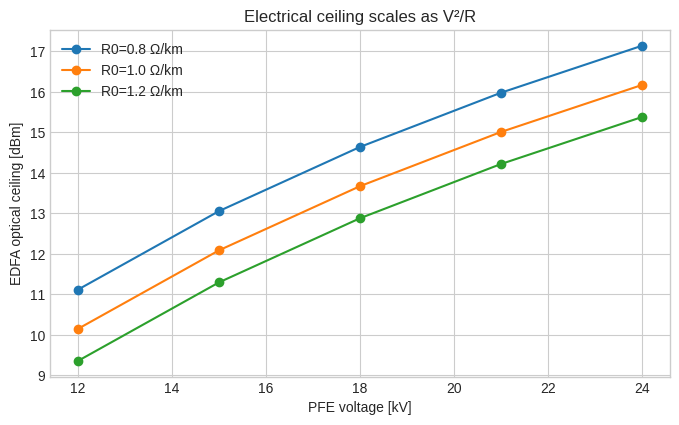

In [8]:
# 최대전력전달의 V^2/R 스케일을 15,000 km, 75 km, 12-SC-FP에서 검산
rows = []
for V_kV in [12, 15, 18, 21, 24]:
    for R in [0.8, 1.0, 1.2]:
        pp = P.copy(); pp['Vpfe_v'] = V_kV*1000; pp['R_ohm_km'] = R
        L, span, fp, eta = 15000, 75, 12, 0.023
        n = int(np.floor(L/span))
        ps = pp['Vpfe_v']**2*(1-pp['epsilon'])*eta/(8*R*L*n*fp)
        rows.append([V_kV, R, n, w2dbm(ps), ps*1e3])
sense = pd.DataFrame(rows, columns=['Vpfe_kV','R_ohm_km','Nrep','EDFA_ceiling_dBm','EDFA_ceiling_mW'])
print(sense.round(3).to_string(index=False))

fig, ax = plt.subplots(figsize=(8,4.5))
for R, d in sense.groupby('R_ohm_km'):
    ax.plot(d.Vpfe_kV, d.EDFA_ceiling_dBm, marker='o', label=f'R0={R} Ω/km')
ax.set(xlabel='PFE voltage [kV]', ylabel='EDFA optical ceiling [dBm]',
       title='Electrical ceiling scales as V²/R')
ax.legend(); plt.show()


## 7. 제공 코드 감사 결과와 수정 권고

1. **`N = floor(Ltot/L_span)`**  
   논문/코드 재현에는 그대로 사용한다. 실제 해저시스템 BOM에서는 보통 필요한 span 수를 `ceil(Ltot/Lspan_max)`로 정하고 terminal span을 어떻게 세는지에 따라 submerged repeater는 span 수보다 하나 적을 수 있다. 두 정의를 혼용하면 ±1 이상의 차이가 생긴다.

2. **빠진 의존성**  
   `help_functions.py`가 없고, `SNR_NoDroop`도 첨부 SNR 파일에 없다. 본 노트북은 필요한 변환함수를 내장하고 `SNR_GD`만 사용했다.

3. **2-dB와 18-dBm 제약**  
   `Ps_nonlinthresh`는 원 함수에서 계산되지만 반환 결과 선정에 사용되지 않는다. 18 dBm도 `Ps` 입력 grid의 상한으로만 간접 구현할 수 있다. 본 노트북은 두 제약을 명시적으로 적용하고 토글로 끌 수 있게 했다.

4. **효율 인덱스**  
   `eta_eo[i, idx_max]`에서 `i`가 단순 후보 span 인덱스다. 실제 표의 gain 축과 후보 span grid가 정확히 일치하지 않으면 보간이 필요하다. 원 효율표를 확보하면 `RegularGridInterpolator`로 gain-output 2D 보간하는 것이 안전하다.

5. **`while` 경계**  
   원 코드는 `idx_max < 1000`을 하드코딩해 `len(Ps)`가 1000이 아닐 때 범위를 벗어날 수 있다. boolean mask 방식으로 바꾸는 것이 안전하다.

6. **최적 launch power 인덱스 오류 가능성**  
   `max_power[i] = Ps[np.argmax(SNR_GD(Ps[:idx_max],...))]`는 현재 동일 시작점이라 동작하지만, 향후 feasible grid가 불연속이면 원 grid 인덱스로 매핑해야 한다.

7. **Shannon 용량의 성격**  
   구현값은 coding gap, implementation penalty, transceiver SNR, guard band를 뺀 이상적 상한이다. 실제 설계 용량으로 쓰려면 GMI/AIR 또는 modem mode table을 적용해야 한다.


## 8. 최종 판단

- Fig. 4의 핵심 논리는 타당하다: SDM으로 pair당 필요 SNR을 낮추면 긴 span과 적은 리피터가 가능하다.
- 최대전력전달 정리는 repeater 수를 직접 결정하는 공식이 아니라, 각 후보 $N_{rep}$에서 가능한 EDFA launch power를 제한하는 전기적 경계조건이다.
- 6,000 km/50 km/12-SC-FP의 전력 예산은 충분해 광 비선형 back-off 또는 18 dBm 제한이 지배하고, 15,000 km/75 km에서는 전력 제약이 지배한다.
- 정량적으로 출판 Fig. 4를 완전히 복제하려면 저자의 $\eta_{eo}(gain,P_s)$ 원 배열과 Fig. 4 driver가 반드시 필요하다. 이를 받으면 본 노트북의 `eta_eo()`와 scenario 입력부만 교체하면 된다.
- 실제 해저시스템 설계에는 PFE 양단 급전/전류 한계, conductor 온도저항, repeater 고정 회로전력, repair margin, terminal repeater counting, modem AIR를 추가해야 한다.

### 참고 위치

- 논문 식 (1)-(8), Fig. 2-4, Table 1: 첨부 PDF pp. 1-5.
- 전력 제한 구현: `Opt_cap_extended_model(7).py`의 `P_elecmax`, `P_maxchannel`, `N=floor(...)` 부분.
- GD/GN-SNR 구현: `snr_calculator_Silas(7).py`의 `SNR_GD`.
